<a href="https://colab.research.google.com/github/Flavio-98/cdProjetoAplicadoIV/blob/master/projeto/cd_projeto_aplicado_IV_etapa_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  <img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2026/01**


# **Entrega 2**

---

# **Titulo do Projeto**: Análise Preditiva e Modelagem de Séries Temporais: Tarifas Aéreas Domésticas (ANAC 2022-2025)

---

In [ ]:
#@title **Identificação do Grupo e Opção do Projeto**

#@title **Identificação do Grupo e Opção do Projeto**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: <nome>, <matrícula>*)
Aluno1 = 'Flavio Estevam Nogueira Andrade, 10441572' #@param {type:"string"}
Aluno2 = 'Kaique Nascimento de Paula, 24024831' #@param {type:"string"}
Aluno3 = 'Miguel Shiraishi, 10431805' #@param {type:"string"}
Aluno4 = 'Moacyr Souza Barros, 10441179' #@param {type:"string"}



# **1 Introdução**

**1.1 Contexto**

O setor aéreo brasileiro é dominado por três grandes empresas: Azul, Gol e Latam. Após o período crítico da pandemia, o mercado passou por uma fase de reorganização, enfrentando mudanças na demanda dos passageiros e custos operacionais variados. Para entender como o setor está hoje, a ANAC (Agência Nacional de Aviação Civil) disponibiliza microdados detalhados sobre todas as tarifas comercializadas no país. Para a realização deste projeto, foram utilizados microdados tarifários brutos extraídos do portal oficial da ANAC. A base completa, composta pelos arquivos CSV consolidados para a análise, está armazenada e disponível para conferência através do seguinte link: https://drive.google.com/drive/folders/1BoLlqGzr8HVCwM1OV2yucq2RszoV8vvh?usp=drive_link

**1.2 Motivação**

A principal motivação deste trabalho é aplicar as técnicas de Ciência de Dados aprendidas no curso para transformar uma base de dados bruta e volumosa em informações visuais. Observar como o equilíbrio de forças entre as três principais companhias aéreas do país e como isso reflete no custo do consumidor. Analisar esses dados permite identificar padrões que não são óbvios apenas lendo notícias ou sites de vendas.

**1.3 Objetivos**

**1.3.1 Objetivo Geral**
Analisar o comportamento do mercado de aviação civil nacional entre os anos de 2022 e 2025, focando na participação de mercado e na evolução dos preços das passagens das três principais companhias aéreas.

**1.3.2 Objetivos Específicos**

- Tratamento de Dados: Utilizar a biblioteca Pandas para filtrar e limpar a base de dados da ANAC, focando apenas nos voos domésticos das empresas alvo.

- Análise de Market Share: Calcular e visualizar a fatia de mercado de cada companhia através de gráficos de setores (pizza).

- Análise Temporal: Gerar gráficos de linha para acompanhar a variação mensal do preço médio das passagens, identificando tendências e sazonalidade.

- Comparação de Performance: Confrontar os dados das três empresas para entender qual delas manteve maior estabilidade de preços e volume de vendas no período.

**1.4 Justificativa**

Este projeto se justifica pela necessidade de monitorar a concentração de mercado em um setor essencial para a economia brasileira. Com a saída de empresas menores e os desafios financeiros das grandes companhias, entender como o market share se distribui e como os preços reagem é fundamental para a análise econômica do setor. Tecnicamente, o projeto justifica-se pelo desafio de manipular grandes volumes de dados provenientes da ANAC, exigindo o uso eficiente de bibliotecas de processamento de dados em Python, como o Pandas, para gerar insights que ferramentas comuns de escritório não suportariam com facilidade.

In [ ]:
from google.colab import drive
import pandas as pd
import zipfile
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

drive.mount('/content/gdrive')

Mounted at /content/gdrive


# **Referencial Teórico**

O foco central deste trabalho é a análise do comportamento dos preços das passagens aéreas, um indicador fundamental para entender a acessibilidade do transporte aéreo e as estratégias das companhias aéreas. O conceito principal envolve o monitoramento da tarifa aérea média doméstica, que reflete as variações de custo conforme a sazonalidade, a demanda e a concorrência entre as empresas (ANAC, 2024). Ao discutir trabalhos correlacionados, nota-se que estudos do setor costumam focar em indicadores macroeconômicos ou relatórios anuais consolidados, muitas vezes utilizando ferramentas de Business Intelligence (BI) ou planilhas eletrônicas como o Excel para o tratamento dos dados. Embora o uso de planilhas seja uma alternativa comum para problemas semelhantes, essa abordagem apresenta limitações críticas de performance e escalabilidade ao processar o volume massivo de microdados tarifários disponibilizados pela ANAC. Em contrapartida, a solução proposta utiliza a linguagem Python e a biblioteca Pandas, oferecendo a vantagem de automatizar o pipeline de limpeza e permitir uma análise temporal granular e precisa. Além do foco nos preços, utiliza-se o conceito de Market Share como uma variável secundária para observar se a concentração de mercado entre as três principais operadoras influencia diretamente na flutuação das tarifas praticadas (MCKINNEY, 2022). Dessa forma, o projeto utiliza técnicas modernas de Ciência de Dados para superar as restrições de ferramentas manuais, garantindo maior reprodutibilidade e profundidade na análise do mercado aéreo.

# **Pipeline da Solução**

O pipeline da solução proposta foi estruturado para garantir a eficiência no processamento do grande volume de microdados tarifários da ANAC. O fluxo se divide em cinco etapas principais:

- Ingestão e Carregamento: Os dados são importados diretamente para o ambiente de desenvolvimento (Google Colab). Devido ao tamanho dos arquivos, utiliza-se a biblioteca Pandas para a leitura otimizada dos CSVs, garantindo que a memória seja utilizada de forma equilibrada.

- Filtragem e Seleção: Nesta etapa, o conjunto de dados é reduzido para focar apenas nos voos domésticos realizados pelas empresas Azul, Gol e Latam entre os anos de 2022 e 2025. Isso elimina ruídos e dados irrelevantes para o objetivo do projeto.

- Pré-processamento e Limpeza: Aqui é feita a padronização dos tipos de dados, como a conversão de datas e valores monetários. Também são tratados valores nulos e removidos registros duplicados ou inconsistentes que possam enviesar a média de preços.

- Processamento e Agrupamento: Os dados são agrupados por mês e por companhia aérea para o cálculo das métricas principais: o preço médio da passagem e o volume de vendas necessário para determinar a participação de mercado.

- Análise Visual e Insights: Na etapa final, as bibliotecas Matplotlib e Seaborn são utilizadas para gerar visualizações gráficas (gráficos de linha para séries temporais e de pizza para market share), permitindo a interpretação final sobre o comportamento dos preços no período analisado.

In [ ]:
import pandas as pd
import numpy as np
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')

caminho_pasta = '/content/drive/MyDrive/Projeto_anac/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
arquivos_zips = [f for f in os.listdir(caminho_pasta) if f.lower().endswith('.zip')]

primeiro_zip = os.path.join(caminho_pasta, arquivos_zips[0])

with zipfile.ZipFile(primeiro_zip, 'r') as z:
    primeiro_csv = z.namelist()[0]
    with z.open(primeiro_csv) as f:
        amostra = pd.read_csv(f, sep=';', encoding='latin1', nrows=5)

print(f"Arquivo analisado: {primeiro_csv}")
print("\nColunas encontradas:")
print(amostra.columns.tolist())
display(amostra.head())

Arquivo analisado: 202201.CSV

Colunas encontradas:
['Ano de Referência', 'Mês de Referência', 'ICAO Empresa Aérea', 'ICAO Aeródromo Origem', 'ICAO Aeródromo Destino', 'Tarifa-N', 'Assentos Comercializados']


,Ano de Referência,Mês de Referência,ICAO Empresa Aérea,ICAO Aeródromo Origem,ICAO Aeródromo Destino,Tarifa-N,Assentos Comercializados
0,2022,1,AZU,SBAC,SBAR,"552,9",1
1,2022,1,AZU,SBAC,SBBR,"614,9",1
2,2022,1,AZU,SBAC,SBCA,"550,9",1
3,2022,1,AZU,SBAC,SBCF,"887,9",1
4,2022,1,AZU,SBAC,SBFL,"438,9",3


In [ ]:
lista_dfs = []

def identificar_colunas(colunas):
    mapa = {}
    for c in colunas:
        c_low = c.lower()
        if 'ano' in c_low or 'nr_ano' in c_low:
            mapa[c] = 'ano'
        elif 'mês' in c_low or 'mes' in c_low or 'nr_mes' in c_low:
            mapa[c] = 'mes'
        elif 'empresa' in c_low or 'sg_empresa' in c_low:
            mapa[c] = 'empresa'
        elif 'origem' in c_low or 'sg_origem' in c_low:
            mapa[c] = 'origem'
        elif 'destino' in c_low or 'sg_destino' in c_low:
            mapa[c] = 'destino'
        elif 'tarifa' in c_low or 'vl_tarifa' in c_low:
            mapa[c] = 'tarifa'
    return mapa

for zip_nome in arquivos_zips:
    with zipfile.ZipFile(os.path.join(caminho_pasta, zip_nome), 'r') as z:
        for csv_nome in z.namelist():
            if csv_nome.lower().endswith('.csv'):
                with z.open(csv_nome) as f:
                    content_preview = f.read(2048).decode('latin1', errors='ignore')
                    sep = ';' if ';' in content_preview else ','
                    f.seek(0)

                    df = pd.read_csv(f, sep=sep, engine='python', encoding='latin1', dtype=str)

                    mapa_cols = identificar_colunas(df.columns)
                    df = df.rename(columns=mapa_cols)

                    manter = ['ano', 'mes', 'empresa', 'origem', 'destino', 'tarifa']
                    cols_presentes = [c for c in manter if c in df.columns]

                    if len(cols_presentes) >= 5:
                        lista_dfs.append(df[cols_presentes].copy())
                        print(f"OK: {csv_nome}")

df_completo = pd.concat(lista_dfs, ignore_index=True)

for col in ['ano', 'mes']:
    df_completo[col] = pd.to_numeric(df_completo[col], errors='coerce').astype('Int16')

if 'tarifa' in df_completo.columns:
    df_completo['tarifa'] = df_completo['tarifa'].str.replace(',', '.')
    df_completo['tarifa'] = pd.to_numeric(df_completo['tarifa'], errors='coerce').astype('float32')

print(f"\n--- DADOS CORRIGIDOS ---")
print(f"Total: {len(df_completo)} linhas")
print("\nAnos:", df_completo['ano'].unique().tolist())
print("Meses:", sorted([m for m in df_completo['mes'].unique() if m is not pd.NA]))
display(df_completo.head())

OK: 202201.CSV
OK: 202202.CSV
OK: 202203.CSV
OK: 202204.CSV
OK: 202205.CSV
OK: 202206.CSV
OK: 202207.CSV
OK: 202208.CSV
OK: 202209.CSV
OK: 202210.CSV
OK: 202211.CSV
OK: 202212.CSV
OK: 202301.CSV
OK: 202302.CSV
OK: 202303.CSV
OK: 202304.CSV
OK: 202305.CSV
OK: 202306.CSV
OK: 202307.CSV
OK: 202308.CSV
OK: 202309.CSV
OK: 202310.CSV
OK: 202311.CSV
OK: 202312.CSV
OK: 202401.CSV
OK: 202402.CSV
OK: 202403.CSV
OK: 202404.CSV
OK: 202405.CSV
OK: 202406.CSV
OK: 202407.CSV
OK: 202408.CSV
OK: 202409.CSV
OK: 202410.CSV
OK: 202411.CSV
OK: 202412.CSV
OK: 202501.CSV
OK: 202502.CSV
OK: 202503.CSV
OK: 202504.CSV
OK: 202505.CSV
OK: 202506.CSV
OK: 202507.CSV
OK: 202508.CSV
OK: 202509.CSV
OK: 202510.CSV
OK: 202511.CSV
OK: 202512.CSV

--- DADOS CORRIGIDOS ---
Total: 26297368 linhas

Anos: [2022, 2023, 2024, 2025]
Meses: [np.int16(1), np.int16(2), np.int16(3), np.int16(4), np.int16(5), np.int16(6), np.int16(7), np.int16(8), np.int16(9), np.int16(10), np.int16(11), np.int16(12)]


,ano,mes,empresa,origem,destino,tarifa
0,2022,1,AZU,SBAC,SBAR,552.900024
1,2022,1,AZU,SBAC,SBBR,614.900024
2,2022,1,AZU,SBAC,SBCA,550.900024
3,2022,1,AZU,SBAC,SBCF,887.900024
4,2022,1,AZU,SBAC,SBFL,438.899994


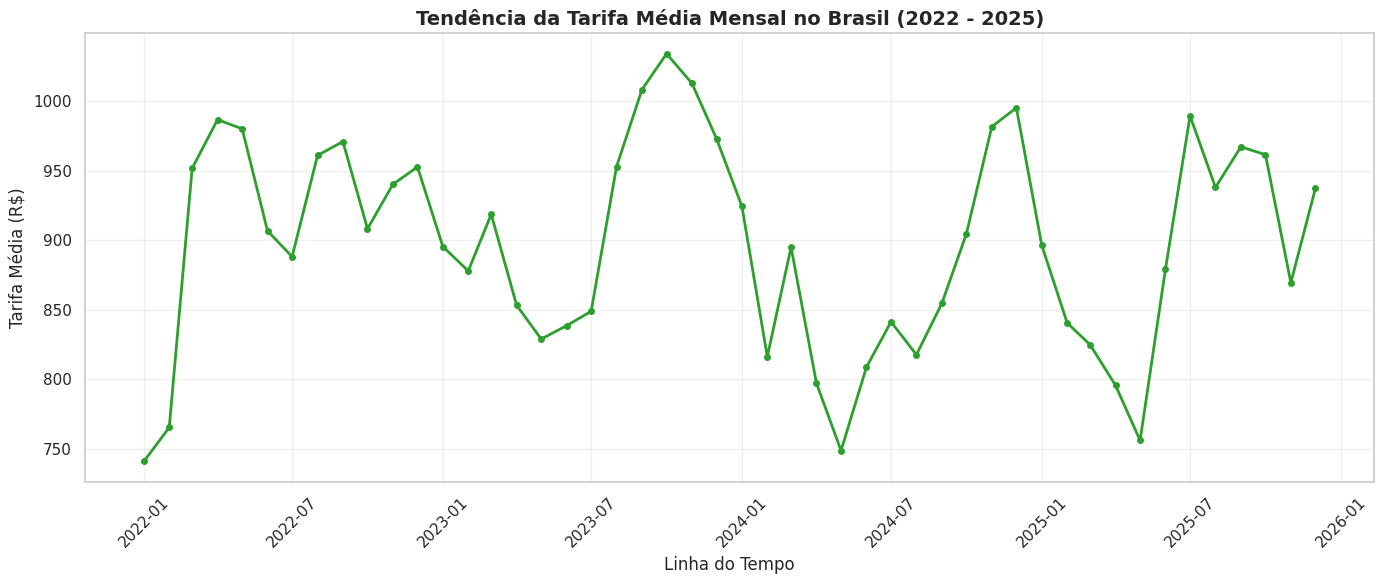

In [ ]:
df_completo['data'] = pd.to_datetime(df_completo['ano'].astype(str) + '-' + df_completo['mes'].astype(str) + '-01')

serie_temporal = df_completo.groupby('data')['tarifa'].mean()

plt.figure(figsize=(14, 6))
plt.plot(serie_temporal.index, serie_temporal.values, color='#2ca02c', marker='o', linestyle='-', linewidth=2, markersize=4)

plt.title('Tendência da Tarifa Média Mensal no Brasil (2022 - 2025)', fontsize=14, fontweight='bold')
plt.ylabel('Tarifa Média (R$)', fontsize=12)
plt.xlabel('Linha do Tempo', fontsize=12)
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

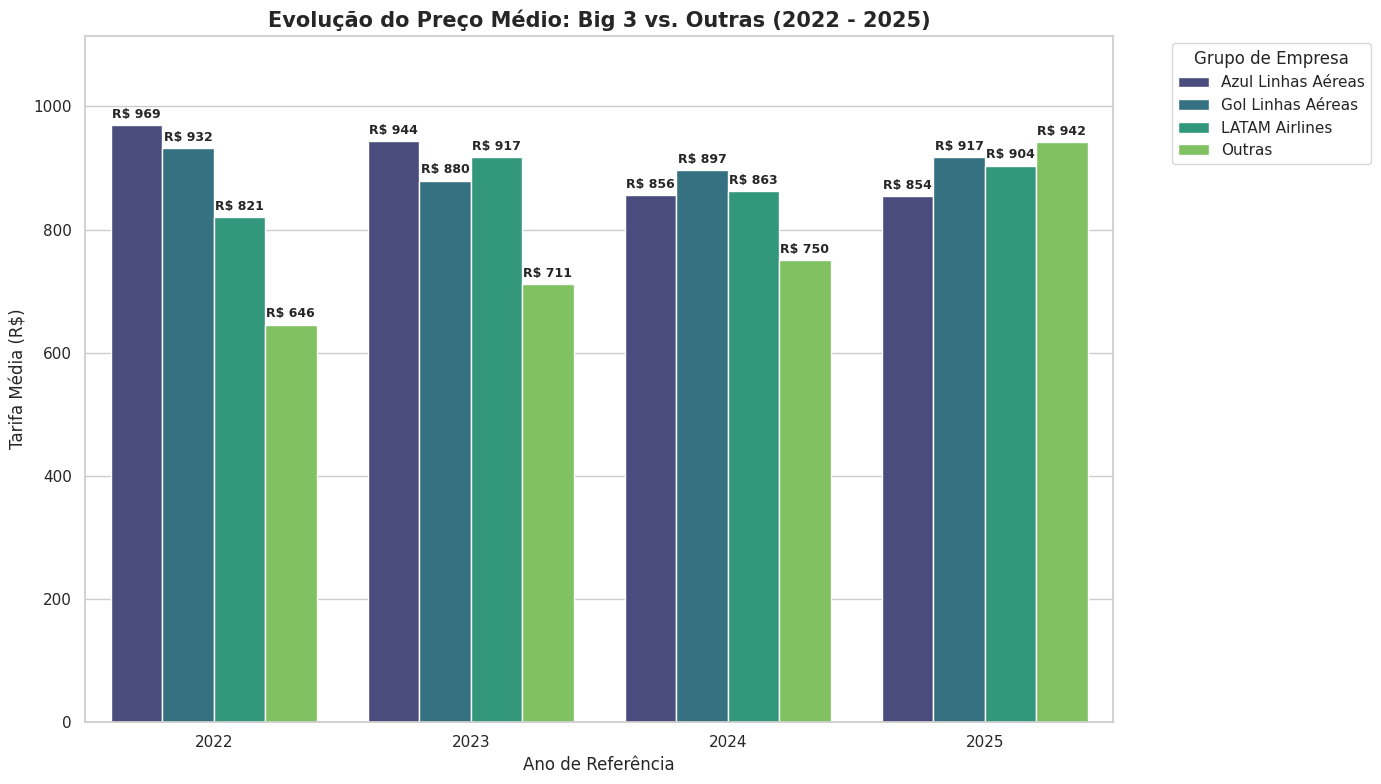

In [ ]:
gigantes = ['AZU', 'GLO', 'TAM']
nomes_map = {
    'AZU': 'Azul Linhas Aéreas',
    'GLO': 'Gol Linhas Aéreas',
    'TAM': 'LATAM Airlines'
}

df_completo['empresa_agrupada'] = df_completo['empresa'].apply(
    lambda x: nomes_map.get(x, x) if x in gigantes else 'Outras'
)

df_anual = df_completo.groupby(['ano', 'empresa_agrupada'])['tarifa'].mean().reset_index()

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

grafico = sns.barplot(
    data=df_anual,
    x='ano',
    y='tarifa',
    hue='empresa_agrupada',
    palette='viridis'
)

for container in grafico.containers:
    grafico.bar_label(container, fmt='R$ %.0f', padding=3, fontsize=9, fontweight='bold')

plt.title('Evolução do Preço Médio: Big 3 vs. Outras (2022 - 2025)', fontsize=15, fontweight='bold')
plt.ylabel('Tarifa Média (R$)', fontsize=12)
plt.xlabel('Ano de Referência', fontsize=12)
plt.legend(title='Grupo de Empresa', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, df_anual['tarifa'].max() * 1.15)

plt.tight_layout()
plt.show()

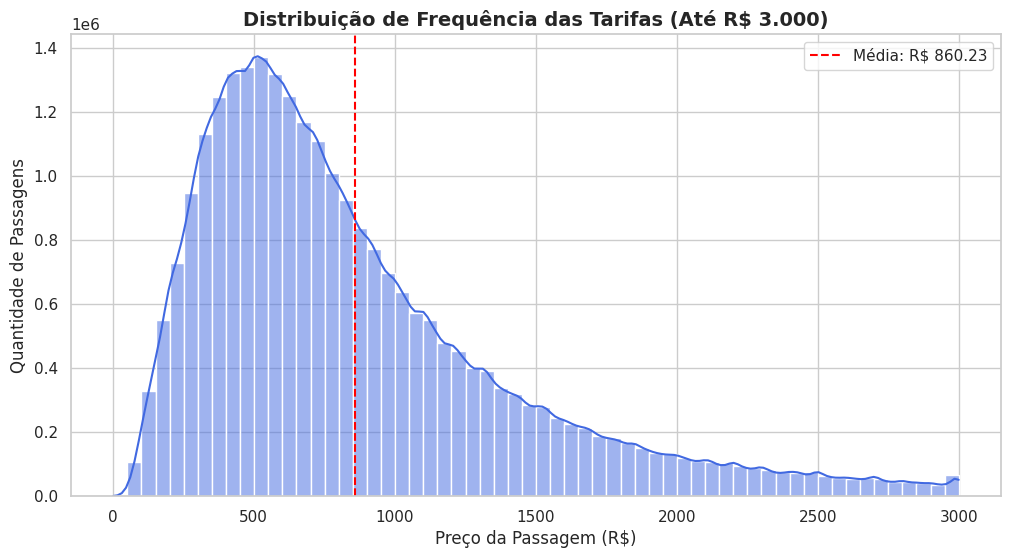

In [ ]:
df_filtrado = df_completo[df_completo['tarifa'] < 3000].copy()
media_val = df_filtrado['tarifa'].mean()

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.histplot(data=df_filtrado, x='tarifa', kde=True, bins=60, color='royalblue')

plt.axvline(media_val, color='red', linestyle='--', label=f'Média: R$ {media_val:.2f}')

plt.title('Distribuição de Frequência das Tarifas (Até R$ 3.000)', fontsize=14, fontweight='bold')
plt.xlabel('Preço da Passagem (R$)', fontsize=12)
plt.ylabel('Quantidade de Passagens', fontsize=12)
plt.legend()

plt.show()

/tmp/ipykernel_63830/2796228258.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


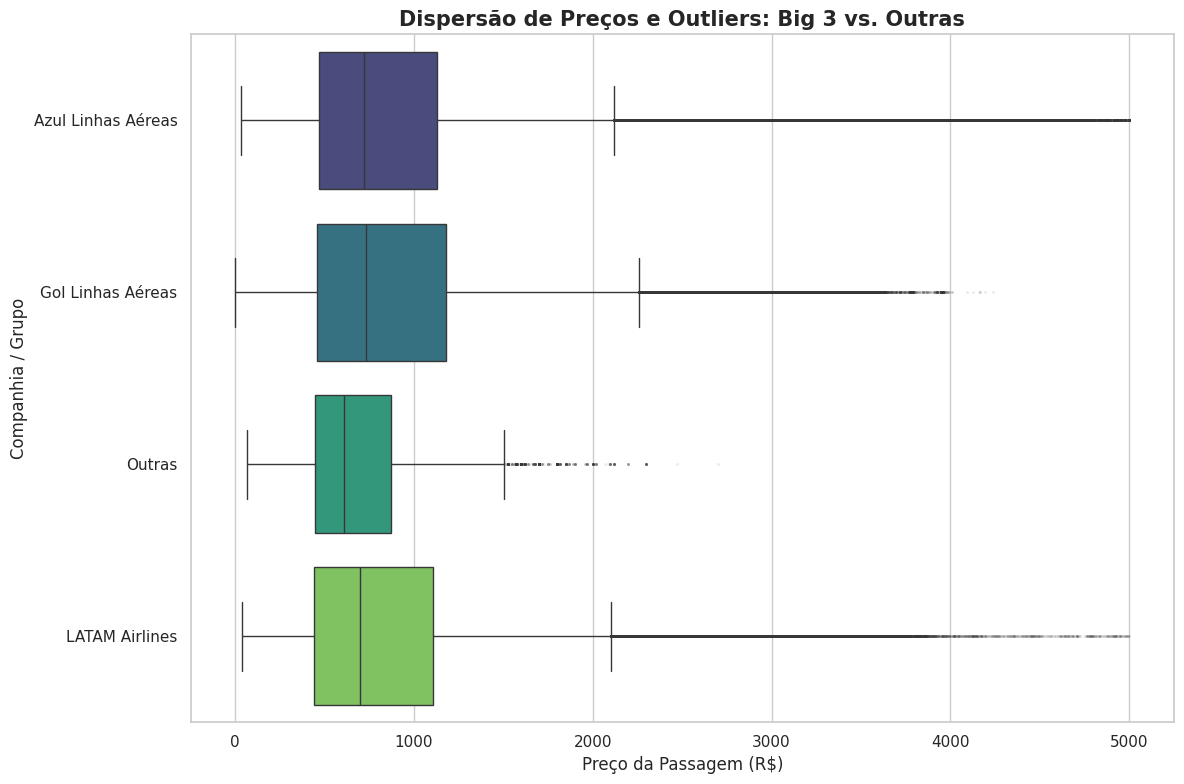

In [ ]:
df_box = df_completo[df_completo['tarifa'] < 5000].copy()

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=df_box,
    x='tarifa',
    y='empresa_agrupada',
    palette='viridis',
    showfliers=True,
    flierprops={"marker": "o", "markersize": 1, "alpha": 0.1}
)

plt.title('Dispersão de Preços e Outliers: Big 3 vs. Outras', fontsize=15, fontweight='bold')
plt.xlabel('Preço da Passagem (R$)', fontsize=12)
plt.ylabel('Companhia / Grupo', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
share_vendas = pd.Series(contagem_total).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
plt.pie(
    share_vendas,
    labels=share_vendas.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired(np.linspace(0, 1, len(share_vendas))),
    pctdistance=0.85,
    explode=[0.05]*len(share_vendas)
)

centro_circulo = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro_circulo)

plt.title('Market Share: Volume de Passagens Vendidas (2022-2025)', fontsize=15, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

# **Cronograma**

| Etapa | Data Limite | Atividades Principais | Status |
| :--- | :--- | :--- | :--- |
| **Etapa 1** | 01/03 | Definição do tema e organização do GitHub. | Concluído |
| **Etapa 2** | 29/03 | Ingestão, Pipeline e EDA (26M registros). | Concluído |
| **Etapa 3** | 26/04 | Implementação de modelos (SARIMA/LSTM). | Em Aberto |
| **Etapa 4** | 31/05 | Análise crítica e Entrega final. | Em Aberto |

# **Referências**
AGÊNCIA NACIONAL DE AVIAÇÃO CIVIL (ANAC). **Microdados de Tarifas Aéreas Comercializadas**. Brasília, DF: ANAC, 2024. Disponível em: https://www.gov.br/anac/pt-br/assuntos/dados-e-estatisticas/microdados-de-tarifas-aereas-comercializadas. Acesso em: 15 abr. 2026.

HUNTER, J. D. **Matplotlib: A 2D graphics environment**. Computing in Science & Engineering, v. 9, n. 3, p. 90-95, 2007.

MCKINNEY, W. **Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython**. 3. ed. Sebastopol: O'Reilly Media, 2022.

PANDAS DEVELOPMENT TEAM. **pandas-dev/pandas: Pandas 2.2.0**. Zenodo, 2024. Disponível em: https://pandas.pydata.org. Acesso em: 15 abr. 2026.

WASKOM, M. L. **Seaborn: statistical data visualization**. Journal of Open Source Software, v. 5, n. 52, p. 2121, 2020.

In [ ]:
#@title **Avaliação**
Referencial_teorico = 10 #@param {type:"slider", min:0, max:10, step:1}

Pipeline_solucao = 10 #@param {type:"slider", min:0, max:10, step:1}

Cronograma = 10 #@param {type:"slider", min:0, max:10, step:1}

In [ ]:
#@title **Nota Final**
nota = 0.45*Referencial_teorico + 0.45*Pipeline_solucao + 0.10*Cronograma

print(f'Nota final do trabalho {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()

lista_nome = []

for i in range(1,6):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_nome.append(lista[0]);")

alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)

Nota final do trabalho 10.0



,nome,nota
0,Aluno 1,10.0
1,Aluno 2,10.0
2,Aluno 3,10.0
3,Aluno 4,10.0
4,Aluno 5,10.0
